# 03. Baseline CNN Model

In [ ]:
import torch
import torch.nn as nn

class ECGNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=7, stride=1, padding=3)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.pool = nn.AdaptiveAvgPool1d(output_size=1)
        self.fc = nn.Linear(in_features=64, out_features=5)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.squeeze(-1)
        x = self.fc(x)
        return x

Check if this model works. 

In [3]:
import torch
from src.model import ECGNet

model = ECGNet()
dummy = torch.randn(64, 1, 360)  # fake batch
out = model(dummy)
print(out.shape)  # should be (64, 5)

torch.Size([64, 5])


## Create datasets

In [4]:
import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from src.model import ECGNet

# load
npz = np.load('../data/processed/beats_split.npz')
X_train = torch.tensor(npz['X_train']).unsqueeze(1)  # (N, 1, 360)
y_train = torch.tensor(npz['y_train'])
X_test  = torch.tensor(npz['X_test']).unsqueeze(1)
y_test  = torch.tensor(npz['y_test'])

print(X_train.shape, y_train.shape)
print(X_test.shape,  y_test.shape)

torch.Size([50995, 1, 360]) torch.Size([50995])
torch.Size([49687, 1, 360]) torch.Size([49687])


In [5]:
train_ds = TensorDataset(X_train, y_train)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 797
Test batches:  777


## Training loop

In [6]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

model     = ECGNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f'Device: {device}')

Device: mps


In [7]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        # 1. move to device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        # 2. zero gradients
        optimizer.zero_grad()
        # 3. forward pass
        y_pred = model(X_batch)
        # 4. compute loss
        loss = criterion(y_pred, y_batch)
        # 5. backward pass
        loss.backward()
        # 6. optimizer step
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)
    
    avg_loss = train_loss / len(train_loader.dataset)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

    

Epoch [1/10], Loss: 0.4008
Epoch [2/10], Loss: 0.3559
Epoch [3/10], Loss: 0.3475
Epoch [4/10], Loss: 0.3288
Epoch [5/10], Loss: 0.2971
Epoch [6/10], Loss: 0.2727
Epoch [7/10], Loss: 0.2586
Epoch [8/10], Loss: 0.2464
Epoch [9/10], Loss: 0.2383
Epoch [10/10], Loss: 0.2317


## Evaluate Predictions

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
from src.data_loader import CLASS_NAMES

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds   = model(X_batch).argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))

              precision    recall  f1-score   support

           N       0.92      0.99      0.95     44235
           S       0.22      0.01      0.01      1837
           V       0.70      0.40      0.51      3220
           F       0.00      0.00      0.00       388
           Q       0.00      0.00      0.00         7

    accuracy                           0.91     49687
   macro avg       0.37      0.28      0.29     49687
weighted avg       0.87      0.91      0.88     49687



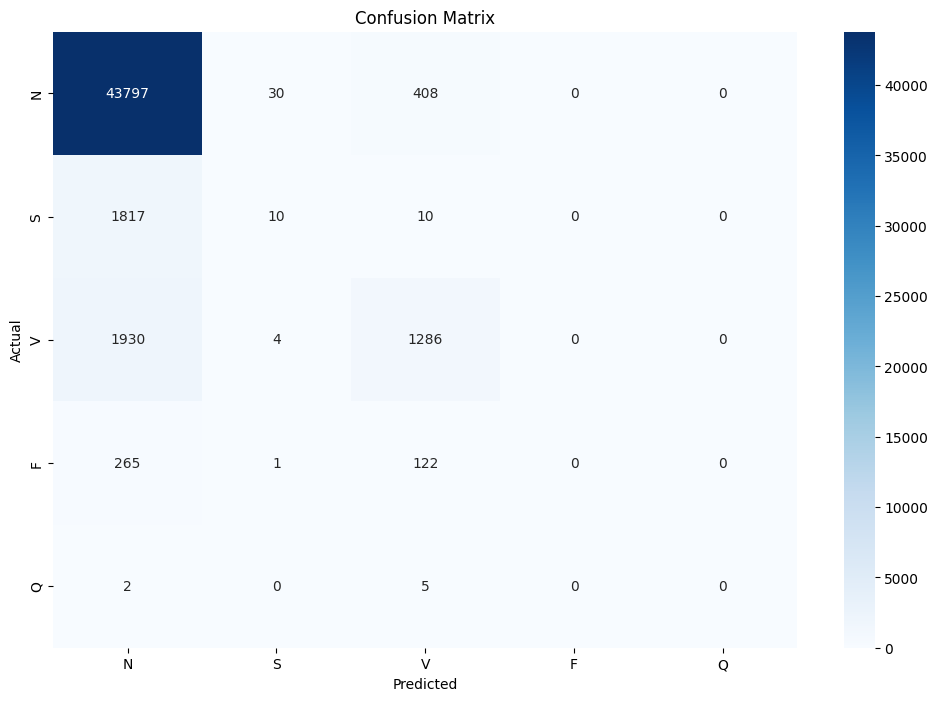

In [22]:
# PLot the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('../results/baseline_cnn_cm_raw.png', dpi=150, bbox_inches='tight')
plt.show()



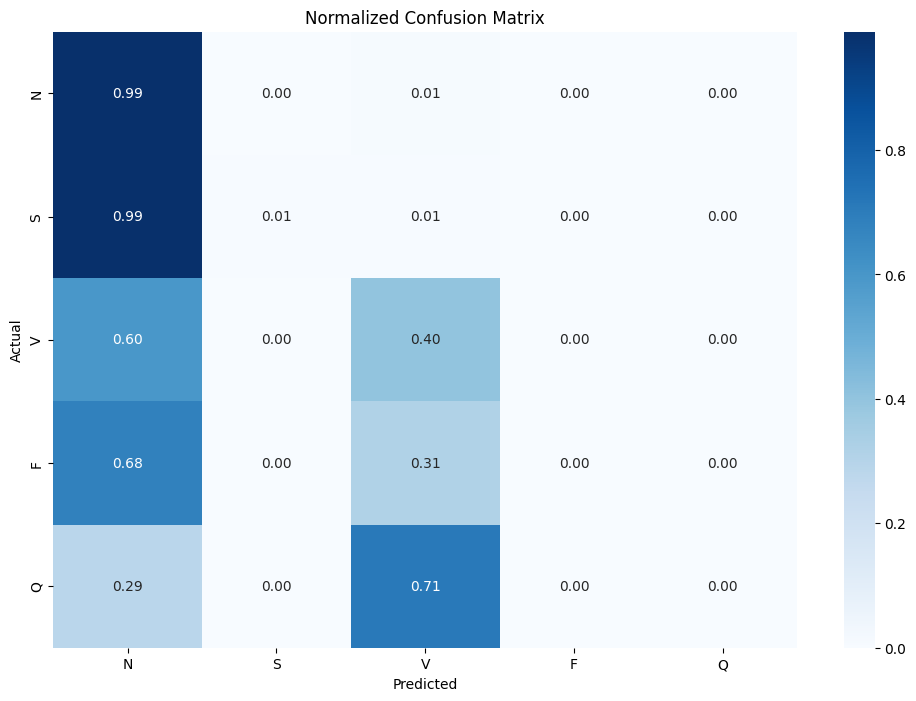

In [23]:
# PLot normalized confusion matrix

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Normalized Confusion Matrix')
plt.savefig('../results/baseline_cnn_cm_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
import json
from sklearn.metrics import f1_score

metrics = {
    'accuracy': float((np.array(all_preds) == np.array(all_labels)).mean()),
    'macro_f1': float(f1_score(all_labels, all_preds, average='macro', zero_division=0)),
    'per_class_f1': {
        name: float(f1_score(all_labels, all_preds, labels=[i], average='micro', zero_division=0))
        for i, name in enumerate(CLASS_NAMES)
    }
}

with open('../results/baseline_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))

{
  "accuracy": 0.9075412079618411,
  "macro_f1": 0.29429319391521763,
  "per_class_f1": {
    "N": 0.9516328792125677,
    "S": 0.010626992561105207,
    "V": 0.5092060978024153,
    "F": 0.0,
    "Q": 0.0
  }
}
